# 02b — Transformação para microdados

**Pré-requisito:** `02_transformacao.ipynb` já executado (`data/processed/sim_evitaveis.parquet` e `feature_matrix.parquet` disponíveis).

**Objetivo:** construir um dataset **individualizado** (1 linha = 1 óbito evitável) para análises por indivíduo (clusterização de perfis de morte, análises de sobrevida, mineração de texto sobre causas). É complementar ao `02_transformacao.ipynb`, que produz o painel agregado por município/ano — este notebook *não substitui* o anterior.

**Diferenças em relação ao 02:**

| Aspecto | 02_transformacao | **02b_transformacao_microdados** |
|---------|------------------|-------------------------------|
| Grão     | município × ano   | 1 óbito                          |
| Tamanho  | ~16.700 linhas    | ~1.366.000 linhas                |
| Uso      | regressão ecológica | clustering de indivíduos, mineração de causas |
| Features | apenas município | demográficas + circunstanciais + município |

## Etapas

1. **Carregar** SIM filtrado (microdados) e feature matrix (contexto municipal).
2. **Decodificar** campos categóricos do SIM (códigos → rótulos legíveis): SEXO, RACACOR, ESTCIV, ESC2010, LOCOCOR, ASSISTMED, NECROPSIA, CIRURGIA, EXAME.
3. **Engenharia de colunas** — `FAIXA_ETARIA`, `MES_OBITO`, capítulo CID-10.
4. **Enriquecer com contexto municipal** — IDH-M, Gini, despesa em saúde etc. (merge por CODMUN6 × ANO).
5. **Sumário do dataset** — shape, tipos, missing.
6. **Estatística descritiva — numéricas** — `describe()` global e por ano.
7. **Estatística descritiva — categóricas** — `value_counts` + proporções por ano.
8. **Histogramas das variáveis numéricas**.
9. **Distribuição das categóricas** — barplots, com comparação entre os 3 anos.
10. **Persistência** — `microdados_evitaveis.parquet`.

**Observação sobre os 3 anos (2022, 2023, 2024):** o dataset contém os três anos. Toda análise descritiva mostra a quebra por ano para visualizar tendências e possíveis efeitos de período (ex.: pós-COVID em 2022 vs. 2023-2024).

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT          = Path.cwd().parent
PROCESSED_DIR = ROOT / "data" / "processed"

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
print("Imports OK")

Imports OK


## 1. Carregar microdados + feature matrix

`sim_evitaveis.parquet` traz ~1.37M óbitos evitáveis (5–74 anos, LBCE excluindo causas externas) já filtrados pelo notebook 02. `feature_matrix.parquet` traz o contexto socioeconômico município × ano.

In [6]:
sim

,ORIGEM,TIPOBITO,DTOBITO,HORAOBITO,NATURAL,CODMUNNATU,DTNASC,IDADE,SEXO,RACACOR,ESTCIV,ESC,ESC2010,SERIESCFAL,OCUP,CODMUNRES,LOCOCOR,CODESTAB,ESTABDESCR,CODMUNOCOR,IDADEMAE,ESCMAE,ESCMAE2010,SERIESCMAE,OCUPMAE,QTDFILVIVO,QTDFILMORT,GRAVIDEZ,SEMAGESTAC,GESTACAO,PARTO,OBITOPARTO,PESO,TPMORTEOCO,OBITOGRAV,OBITOPUERP,ASSISTMED,EXAME,CIRURGIA,NECROPSIA,LINHAA,LINHAB,LINHAC,LINHAD,LINHAII,CAUSABAS,CB_PRE,COMUNSVOIM,DTATESTADO,CIRCOBITO,ACIDTRAB,FONTE,NUMEROLOTE,TPPOS,DTINVESTIG,CAUSABAS_O,DTCADASTRO,ATESTANTE,STCODIFICA,CODIFICADO,VERSAOSIST,VERSAOSCB,FONTEINV,DTRECEBIM,ATESTADO,DTRECORIGA,CAUSAMAT,ESCMAEAGR1,ESCFALAGR1,STDOEPIDEM,STDONOVA,DIFDATA,NUDIASOBCO,NUDIASOBIN,DTCADINV,TPOBITOCOR,DTCONINV,FONTES,TPRESGINFO,TPNIVELINV,NUDIASINF,DTCADINF,MORTEPARTO,DTCONCASO,FONTESINF,ALTCAUSA,CONTADOR,_arquivo,IDADE_ANOS,ANO_OBITO,GRUPO_LBCE,EVITAVEL
0,1,2,2022-05-14,0345,812,120017,1959-02-13,463,2,4,2,1,0,NaN,NaN,120017,3,NaN,NaN,120017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,*I461,NaN,NaN,*I10X,NaN,I10,NaN,NaN,14052022,NaN,NaN,NaN,20220006,S,17052022,I10,20062022,NaN,S,S,3.2.30,3.4,2,29062022,I461/ / /I10,29062022,NaN,NaN,00,0,1,046,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1537,DOAC2022.parquet,63.0,2022,doencas_nao_transmissiveis,True
1,1,2,2022-02-23,1820,812,120060,1965-09-30,456,1,4,2,1,0,NaN,NaN,120020,1,5336171,NaN,120020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,2,*I619,*I10X,NaN,NaN,*I48X,I619,NaN,NaN,23022022,NaN,NaN,NaN,20230013,NaN,NaN,I619,20042022,5,S,S,3.2.30,3.4,NaN,20062023,I619/I10*I48,19052022,NaN,NaN,00,0,1,482,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10641,DOAC2022.parquet,56.0,2022,doencas_nao_transmissiveis,True
2,1,2,2022-02-23,0743,812,120020,1954-09-22,467,1,2,2,3,1,4,999993,120020,1,5336171,NaN,120020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,2,*A419,*K650,*K440,NaN,NaN,K440,NaN,NaN,23022022,NaN,NaN,NaN,20230013,NaN,NaN,K440,20042022,2,S,S,3.2.30,3.4,NaN,20062023,A419/K650/K440,19052022,NaN,NaN,02,0,1,482,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11387,DOAC2022.parquet,67.0,2022,doencas_nao_transmissiveis,True
3,1,2,2022-02-20,1725,NaN,NaN,1947-11-21,474,1,4,2,NaN,NaN,NaN,999993,120020,1,5336171,NaN,120020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,2,*A419,*I500,NaN,NaN,*S880*E149,I500,NaN,NaN,20022022,NaN,NaN,NaN,20230013,NaN,NaN,I500,20042022,2,S,S,3.2.30,3.4,NaN,20062023,A419/I500*S880 E149,19052022,NaN,NaN,NaN,0,1,485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11390,DOAC2022.parquet,74.0,2022,doencas_nao_transmissiveis,True
4,1,2,2022-01-06,2018,812,120070,1957-04-12,464,1,4,9,9,9,NaN,354705,120070,1,2001578,NaN,120040,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,*I509,*I678,NaN,NaN,NaN,I678,NaN,NaN,06012022,NaN,NaN,NaN,20220003,N,NaN,I678,25022022,NaN,S,S,3.2.30,3.4,NaN,22032022,I509/I678,22032022,NaN,NaN,09,0,1,075,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13618,DOAC2022.parquet,64.0,2022,doencas_nao_transmissiveis,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1366462,1,2,2024-12-31,1843,825,251360,1950-10-20,474,2,4,4,1,0,NaN,999993,172100,1,2891662,NaN,172100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,2,*N179,*A419,NaN,NaN,*I509*J449,A419,NaN,NaN,31122024,NaN,NaN,NaN,20250007,NaN,NaN,A419,22012025,1,S,S,3.2.30,4.3,NaN,27012025,N179/A419 / / /I509*J449,27012025,NaN,NaN,00,0,1,027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1528583,DOTO2024.parquet,74.0,2024,doencas_infecciosas,True
1366463,1,2,2024-12-3

In [2]:
sim = pd.read_parquet(PROCESSED_DIR / "sim_evitaveis.parquet")
fm  = pd.read_parquet(PROCESSED_DIR / "feature_matrix.parquet")

sim["CODMUNRES"] = sim["CODMUNRES"].astype(str).str.zfill(6)
sim["ANO_OBITO"] = sim["ANO_OBITO"].astype("Int64")
fm["CODMUN6"]    = fm["CODMUN6"].astype(str).str.zfill(6)
fm["ANO"]        = fm["ANO"].astype(int)

print(f"SIM evitáveis     : {sim.shape[0]:>10,} óbitos × {sim.shape[1]} colunas")
print(f"Feature matrix    : {fm.shape[0]:>10,} obs × {fm.shape[1]} colunas")
print(f"Anos no SIM       : {sorted(sim['ANO_OBITO'].dropna().unique().tolist())}")

SIM evitáveis     :  1,366,467 óbitos × 92 colunas
Feature matrix    :     16,711 obs × 33 colunas
Anos no SIM       : [2022, 2023, 2024]


## 2. Decodificar campos categóricos do SIM

O SIM usa códigos numéricos curtos. Para análise descritiva e clusterização, traduzimos para rótulos legíveis seguindo o dicionário oficial DATASUS/SVS-MS.

| Campo | Significado |
|-------|-------------|
| SEXO       | sexo biológico |
| RACACOR    | raça/cor declarada |
| ESTCIV     | estado civil |
| ESC2010    | escolaridade (codificação pós-2010) |
| LOCOCOR    | local de ocorrência do óbito |
| ASSISTMED  | recebeu assistência médica |
| NECROPSIA  | foi realizada necropsia |
| CIRURGIA   | foi realizada cirurgia |
| EXAME      | foram realizados exames complementares |

In [3]:
MAPAS_SIM = {
    "SEXO": {
        "0": "Ignorado", "1": "Masculino", "2": "Feminino", "9": "Ignorado",
    },
    "RACACOR": {
        "1": "Branca", "2": "Preta", "3": "Amarela", "4": "Parda", "5": "Indígena",
    },
    "ESTCIV": {
        "1": "Solteiro", "2": "Casado", "3": "Viúvo",
        "4": "Separado/Divorciado", "5": "União estável", "9": "Ignorado",
    },
    "ESC2010": {
        "0": "Sem escolaridade",
        "1": "Fundamental I (1ª-4ª)",
        "2": "Fundamental II (5ª-8ª)",
        "3": "Ensino Médio",
        "4": "Superior incompleto",
        "5": "Superior completo",
        "9": "Ignorado",
    },
    "LOCOCOR": {
        "1": "Hospital", "2": "Outro estab. saúde", "3": "Domicílio",
        "4": "Via pública", "5": "Outros", "6": "Aldeia indígena", "9": "Ignorado",
    },
    "ASSISTMED":  {"1": "Sim", "2": "Não", "9": "Ignorado"},
    "NECROPSIA":  {"1": "Sim", "2": "Não", "9": "Ignorado"},
    "CIRURGIA":   {"1": "Sim", "2": "Não", "9": "Ignorado"},
    "EXAME":      {"1": "Sim", "2": "Não", "9": "Ignorado"},
}

def aplicar_mapa(serie: pd.Series, mapa: dict, default: str = "Ignorado") -> pd.Series:
    """Aplica o mapa de códigos → rótulos, preservando NaN e mapeando códigos não previstos para `default`."""
    s = serie.astype(str).str.strip()
    return s.map(mapa).fillna(default).astype("category")

md = sim.copy()
for campo, mapa in MAPAS_SIM.items():
    if campo in md.columns:
        md[f"{campo}_LBL"] = aplicar_mapa(md[campo], mapa)

# Sanidade: confere o resultado de uma das colunas
print("SEXO_LBL value counts:")
print(md["SEXO_LBL"].value_counts(dropna=False))
print("\nESC2010_LBL value counts:")
print(md["ESC2010_LBL"].value_counts(dropna=False))

SEXO_LBL value counts:
SEXO_LBL
Masculino    790559
Feminino     575833
Ignorado         75
Name: count, dtype: int64

ESC2010_LBL value counts:
ESC2010_LBL
Fundamental I (1ª-4ª)     415092
Fundamental II (5ª-8ª)    257819
Ensino Médio              253383
Ignorado                  187058
Sem escolaridade          154353
Superior completo          80569
Superior incompleto        18193
Name: count, dtype: int64


## 3. Engenharia de colunas

Variáveis derivadas para uso posterior em clustering:

- **`FAIXA_ETARIA`** — discretiza `IDADE_ANOS` em 5 faixas (5-14, 15-29, 30-49, 50-64, 65-74). Captura padrões etários sem assumir efeito linear.
- **`MES_OBITO`** — mês do óbito (1-12), útil para sazonalidade.
- **`CID_CAPITULO`** — primeira letra do CID-10 (`A`-`Z`), capítulo amplo da classificação.

In [4]:
# Faixa etária
bins   = [5, 15, 30, 50, 65, 75]
labels = ["5-14", "15-29", "30-49", "50-64", "65-74"]
md["FAIXA_ETARIA"] = pd.cut(md["IDADE_ANOS"], bins=bins, labels=labels, right=False, include_lowest=True).astype("category")

# Mês do óbito
md["MES_OBITO"] = md["DTOBITO"].dt.month.astype("Int64")

# Capítulo CID-10 (primeira letra)
md["CID_CAPITULO"] = md["CAUSABAS"].astype(str).str[0].astype("category")

print("FAIXA_ETARIA:")
print(md["FAIXA_ETARIA"].value_counts().sort_index())
print("\nMES_OBITO (top 12):")
print(md["MES_OBITO"].value_counts().sort_index())
print("\nCID_CAPITULO (top 10):")
print(md["CID_CAPITULO"].value_counts().head(10))

FAIXA_ETARIA:
FAIXA_ETARIA
5-14       5878
15-29     33248
30-49    216544
50-64    518589
65-74    592208
Name: count, dtype: int64

MES_OBITO (top 12):
MES_OBITO
1     118411
2     101336
3     113670
4     115105
5     122891
6     120530
7     120724
8     115734
9     110105
10    110831
11    107278
12    109852
Name: count, dtype: Int64

CID_CAPITULO (top 10):
CID_CAPITULO
I    494017
C    298677
J    182389
E    126844
A     70489
K     66653
B     41589
N     37380
F     22348
G     12814
Name: count, dtype: int64


## 4. Enriquecer com contexto municipal

Junta cada óbito com as variáveis socioeconômicas do município de residência (CODMUN6) **no ano do óbito** (ANO_OBITO). Isso permite clusters mistos — "perfil de morte" × "perfil de município".

In [5]:
fm_join = fm[[
    "CODMUN6", "ANO", "UF", "REGIAO",
    "POPULACAO", "LOG_POPULACAO",
    "IDHM", "IDHM_E", "IDHM_L", "IDHM_R",
    "GINI", "RDPC", "PMPOB", "T_ANALF15M", "T_AGUA", "ESPVIDA",
    "PIB_PER_CAPITA", "DESPESA_SAUDE_PC",
    "TAXA_EVITAVEL_100K",   # taxa do próprio município (não a do indivíduo)
]].rename(columns={"CODMUN6": "CODMUNRES", "ANO": "ANO_OBITO"})
fm_join["ANO_OBITO"] = fm_join["ANO_OBITO"].astype("Int64")

md = md.merge(fm_join, on=["CODMUNRES", "ANO_OBITO"], how="left")

# Cobertura do merge
print(f"Total de óbitos       : {len(md):,}")
print(f"Com contexto municipal: {md['IDHM'].notna().sum():,} ({md['IDHM'].notna().mean()*100:.2f}%)")
print(f"Sem contexto (perdidos): {md['IDHM'].isna().sum():,}")

Total de óbitos       : 1,366,467
Com contexto municipal: 1,365,296 (99.91%)
Sem contexto (perdidos): 1,171


## 5. Dataset final — visão geral

Seleciona as colunas relevantes para clusterização e descarta os campos brutos do SIM que não foram decodificados ou são redundantes.

In [6]:
COLS_INDIVIDUO = [
    "IDADE_ANOS", "FAIXA_ETARIA",
    "SEXO_LBL", "RACACOR_LBL", "ESTCIV_LBL", "ESC2010_LBL",
    "LOCOCOR_LBL", "ASSISTMED_LBL", "NECROPSIA_LBL", "CIRURGIA_LBL", "EXAME_LBL",
    "GRUPO_LBCE", "CAUSABAS", "CID_CAPITULO",
]
COLS_TEMPO    = ["ANO_OBITO", "MES_OBITO"]
COLS_LOCAL    = ["CODMUNRES", "UF", "REGIAO"]
COLS_CONTEXTO = [
    "POPULACAO", "LOG_POPULACAO",
    "IDHM", "IDHM_E", "IDHM_L", "IDHM_R",
    "GINI", "RDPC", "PMPOB", "T_ANALF15M", "T_AGUA", "ESPVIDA",
    "PIB_PER_CAPITA", "DESPESA_SAUDE_PC", "TAXA_EVITAVEL_100K",
]

CORE = COLS_TEMPO + COLS_LOCAL + COLS_INDIVIDUO + COLS_CONTEXTO
mi = md[CORE].copy()

print(f"Microdados finais  : {mi.shape[0]:,} óbitos × {mi.shape[1]} colunas")
print(f"\nMissing por coluna (% não-nulos):")
print((mi.notna().mean()*100).round(1).sort_values())

Microdados finais  : 1,366,467 óbitos × 34 colunas



Missing por coluna (% não-nulos):
DESPESA_SAUDE_PC       98.8
UF                     99.9
RDPC                   99.9
REGIAO                 99.9
PMPOB                  99.9
ESPVIDA                99.9
T_AGUA                 99.9
PIB_PER_CAPITA         99.9
IDHM_R                 99.9
GINI                   99.9
IDHM_E                 99.9
IDHM_L                 99.9
LOG_POPULACAO          99.9
IDHM                   99.9
POPULACAO              99.9
T_ANALF15M             99.9
TAXA_EVITAVEL_100K     99.9
CIRURGIA_LBL          100.0
EXAME_LBL             100.0
ASSISTMED_LBL         100.0
LOCOCOR_LBL           100.0
ESC2010_LBL           100.0
NECROPSIA_LBL         100.0
RACACOR_LBL           100.0
SEXO_LBL              100.0
FAIXA_ETARIA          100.0
IDADE_ANOS            100.0
CODMUNRES             100.0
ANO_OBITO             100.0
CAUSABAS              100.0
ESTCIV_LBL            100.0
MES_OBITO             100.0
GRUPO_LBCE            100.0
CID_CAPITULO          100.0
dtype: float

## 6. Estatística descritiva — variáveis numéricas

`describe()` global + média por ano para detectar drift entre 2022, 2023 e 2024.

In [7]:
vars_num = [c for c in CORE if pd.api.types.is_numeric_dtype(mi[c]) and c != "ANO_OBITO"]
print(f"Variáveis numéricas analisadas ({len(vars_num)}): {vars_num}\n")

summary = mi[vars_num].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T.round(2)
summary["cobertura_%"] = (mi[vars_num].notna().mean() * 100).round(1).values
summary

Variáveis numéricas analisadas (17): ['MES_OBITO', 'IDADE_ANOS', 'POPULACAO', 'LOG_POPULACAO', 'IDHM', 'IDHM_E', 'IDHM_L', 'IDHM_R', 'GINI', 'RDPC', 'PMPOB', 'T_ANALF15M', 'T_AGUA', 'ESPVIDA', 'PIB_PER_CAPITA', 'DESPESA_SAUDE_PC', 'TAXA_EVITAVEL_100K']



,count,mean,std,min,5%,25%,50%,75%,95%,max,cobertura_%
MES_OBITO,1366467.0,6.460913,3.409229,1.0,1.0,4.0,6.0,9.0,12.0,12.0,100.0
IDADE_ANOS,1366467.0,59.553663,12.260175,5.0,35.0,53.0,63.0,69.0,73.0,74.0,100.0
POPULACAO,1365676.0,1256460.992366,2835531.186609,833.0,7848.0,34445.0,158813.0,748919.0,11451999.0,11895578.0,99.9
LOG_POPULACAO,1365676.0,12.091261,2.068713,6.726233,8.968141,10.447148,11.975489,13.526387,16.253675,16.291677,99.9
IDHM,1365296.0,0.72389,0.073388,0.418,0.576,0.684,0.739,0.779,0.809,0.862,99.9
IDHM_E,1365296.0,0.641673,0.093506,0.207,0.455,0.587,0.663,0.719,0.752,0.825,99.9
IDHM_L,1365296.0,0.826192,0.037701,0.672,0.75,0.809,0.835,0.855,0.873,0.894,99.9
IDHM_R,1365296.0,0.71903,0.089405,0.4,0.549,0.671,0.73,0.778,0.843,0.891,99.9
GINI,1365296.0,0.528155,0.068014,0.28,0.42,0.48,0.53,0.58,0.62,0.8,99.9
RDPC,1365296.0,807.761298,407.500027,96.25,244.3,519.95,749.86,1014.0,1516.21,2043.74,99.9


In [8]:
print("Média por ano (drift entre os 3 anos):")
(mi.groupby("ANO_OBITO")[vars_num].mean().round(2)).T

Média por ano (drift entre os 3 anos):


ANO_OBITO,2022,2023,2024
MES_OBITO,6.4,6.52,6.46
IDADE_ANOS,59.51,59.55,59.6
POPULACAO,1242330.57,1235472.86,1290031.45
LOG_POPULACAO,12.07,12.08,12.12
IDHM,0.72,0.72,0.72
IDHM_E,0.64,0.64,0.64
IDHM_L,0.83,0.83,0.83
IDHM_R,0.72,0.72,0.72
GINI,0.53,0.53,0.53
RDPC,807.22,807.79,808.25


## 7. Estatística descritiva — variáveis categóricas

`value_counts` para cada categórica. Mostra contagens absolutas e percentuais (sobre o total não-nulo).

In [9]:
vars_cat = [c for c in CORE if not pd.api.types.is_numeric_dtype(mi[c]) and c not in ("CODMUNRES", "CAUSABAS")]

for c in vars_cat:
    s = mi[c].astype("object")
    counts = s.value_counts(dropna=False)
    pct    = (counts / counts.sum() * 100).round(2)
    tabela = pd.DataFrame({"n": counts, "%": pct}).head(20)
    print(f"--- {c} (cobertura: {s.notna().mean()*100:.1f}%, distintos: {s.nunique()}) ---")
    print(tabela.to_string())
    print()

--- UF (cobertura: 99.9%, distintos: 27) ---
         n      %
UF               
SP  316060  23.13
RJ  135887   9.94
MG  135182   9.89
RS   89908   6.58
BA   88907   6.51
PR   81210   5.94
PE   63347   4.64
CE   50631   3.71
SC   47635   3.49
GO   46212   3.38
PA   41470   3.03
MA   37270   2.73
ES   27071   1.98
PB   26459   1.94
AL   22988   1.68
RN   20739   1.52
PI   20733   1.52
MT   20707   1.52
MS   19759   1.45
AM   19252   1.41

--- REGIAO (cobertura: 99.9%, distintos: 5) ---


             n      %
REGIAO               
SE      614200  44.95
NE      343787  25.16
S       218753  16.01
CO      100060   7.32
N        88876   6.50
NaN        791   0.06

--- FAIXA_ETARIA (cobertura: 100.0%, distintos: 5) ---
                   n      %
FAIXA_ETARIA               
65-74         592208  43.34
50-64         518589  37.95
30-49         216544  15.85
15-29          33248   2.43
5-14            5878   0.43



--- SEXO_LBL (cobertura: 100.0%, distintos: 3) ---
                n      %
SEXO_LBL                
Masculino  790559  57.85
Feminino   575833  42.14
Ignorado       75   0.01

--- RACACOR_LBL (cobertura: 100.0%, distintos: 6) ---
                  n      %
RACACOR_LBL               
Branca       621761  45.50
Parda        565973  41.42
Preta        148146  10.84
Ignorado      20143   1.47
Amarela        6273   0.46
Indígena       4171   0.31



--- ESTCIV_LBL (cobertura: 100.0%, distintos: 6) ---
                          n      %
ESTCIV_LBL                        
Casado               484726  35.47
Solteiro             449032  32.86
Viúvo                145556  10.65
Separado/Divorciado  141920  10.39
Ignorado              83577   6.12
União estável         61656   4.51

--- ESC2010_LBL (cobertura: 100.0%, distintos: 7) ---
                             n      %
ESC2010_LBL                          
Fundamental I (1ª-4ª)   415092  30.38
Fundamental II (5ª-8ª)  257819  18.87
Ensino Médio            253383  18.54
Ignorado                187058  13.69
Sem escolaridade        154353  11.30
Superior completo        80569   5.90
Superior incompleto      18193   1.33



--- LOCOCOR_LBL (cobertura: 100.0%, distintos: 7) ---
                         n      %
LOCOCOR_LBL                      
Hospital            966870  70.76
Domicílio           248578  18.19
Outro estab. saúde  113739   8.32
Outros               25214   1.85
Via pública          11692   0.86
Ignorado               343   0.03
Aldeia indígena         31   0.00

--- ASSISTMED_LBL (cobertura: 100.0%, distintos: 3) ---
                    n      %
ASSISTMED_LBL               
Sim            783624  57.35
Ignorado       483864  35.41
Não             98979   7.24

--- NECROPSIA_LBL (cobertura: 100.0%, distintos: 3) ---
                    n      %
NECROPSIA_LBL               
Não            832274  60.91
Ignorado       433006  31.69
Sim            101187   7.41



--- CIRURGIA_LBL (cobertura: 100.0%, distintos: 3) ---
                    n      %
CIRURGIA_LBL                
Ignorado      1363987  99.82
Não              2446   0.18
Sim                34   0.00

--- EXAME_LBL (cobertura: 100.0%, distintos: 3) ---
                 n      %
EXAME_LBL                
Ignorado   1363799  99.80
Não           2012   0.15
Sim            656   0.05



--- GRUPO_LBCE (cobertura: 100.0%, distintos: 4) ---
                                  n      %
GRUPO_LBCE                                
doencas_nao_transmissiveis  1109236  81.18
doencas_infecciosas          250735  18.35
morte_materna                  4827   0.35
imunoprevencao                 1669   0.12

--- CID_CAPITULO (cobertura: 100.0%, distintos: 12) ---
                   n      %
CID_CAPITULO               
I             494017  36.15
C             298677  21.86
J             182389  13.35
E             126844   9.28
A              70489   5.16
K              66653   4.88
B              41589   3.04
N              37380   2.74
F              22348   1.64
G              12814   0.94
L               8440   0.62
O               4827   0.35



## 8. Histogramas — variáveis numéricas

Grade de histogramas para todas as variáveis numéricas. Atalho rápido para detectar caudas longas, multimodalidade e outliers.

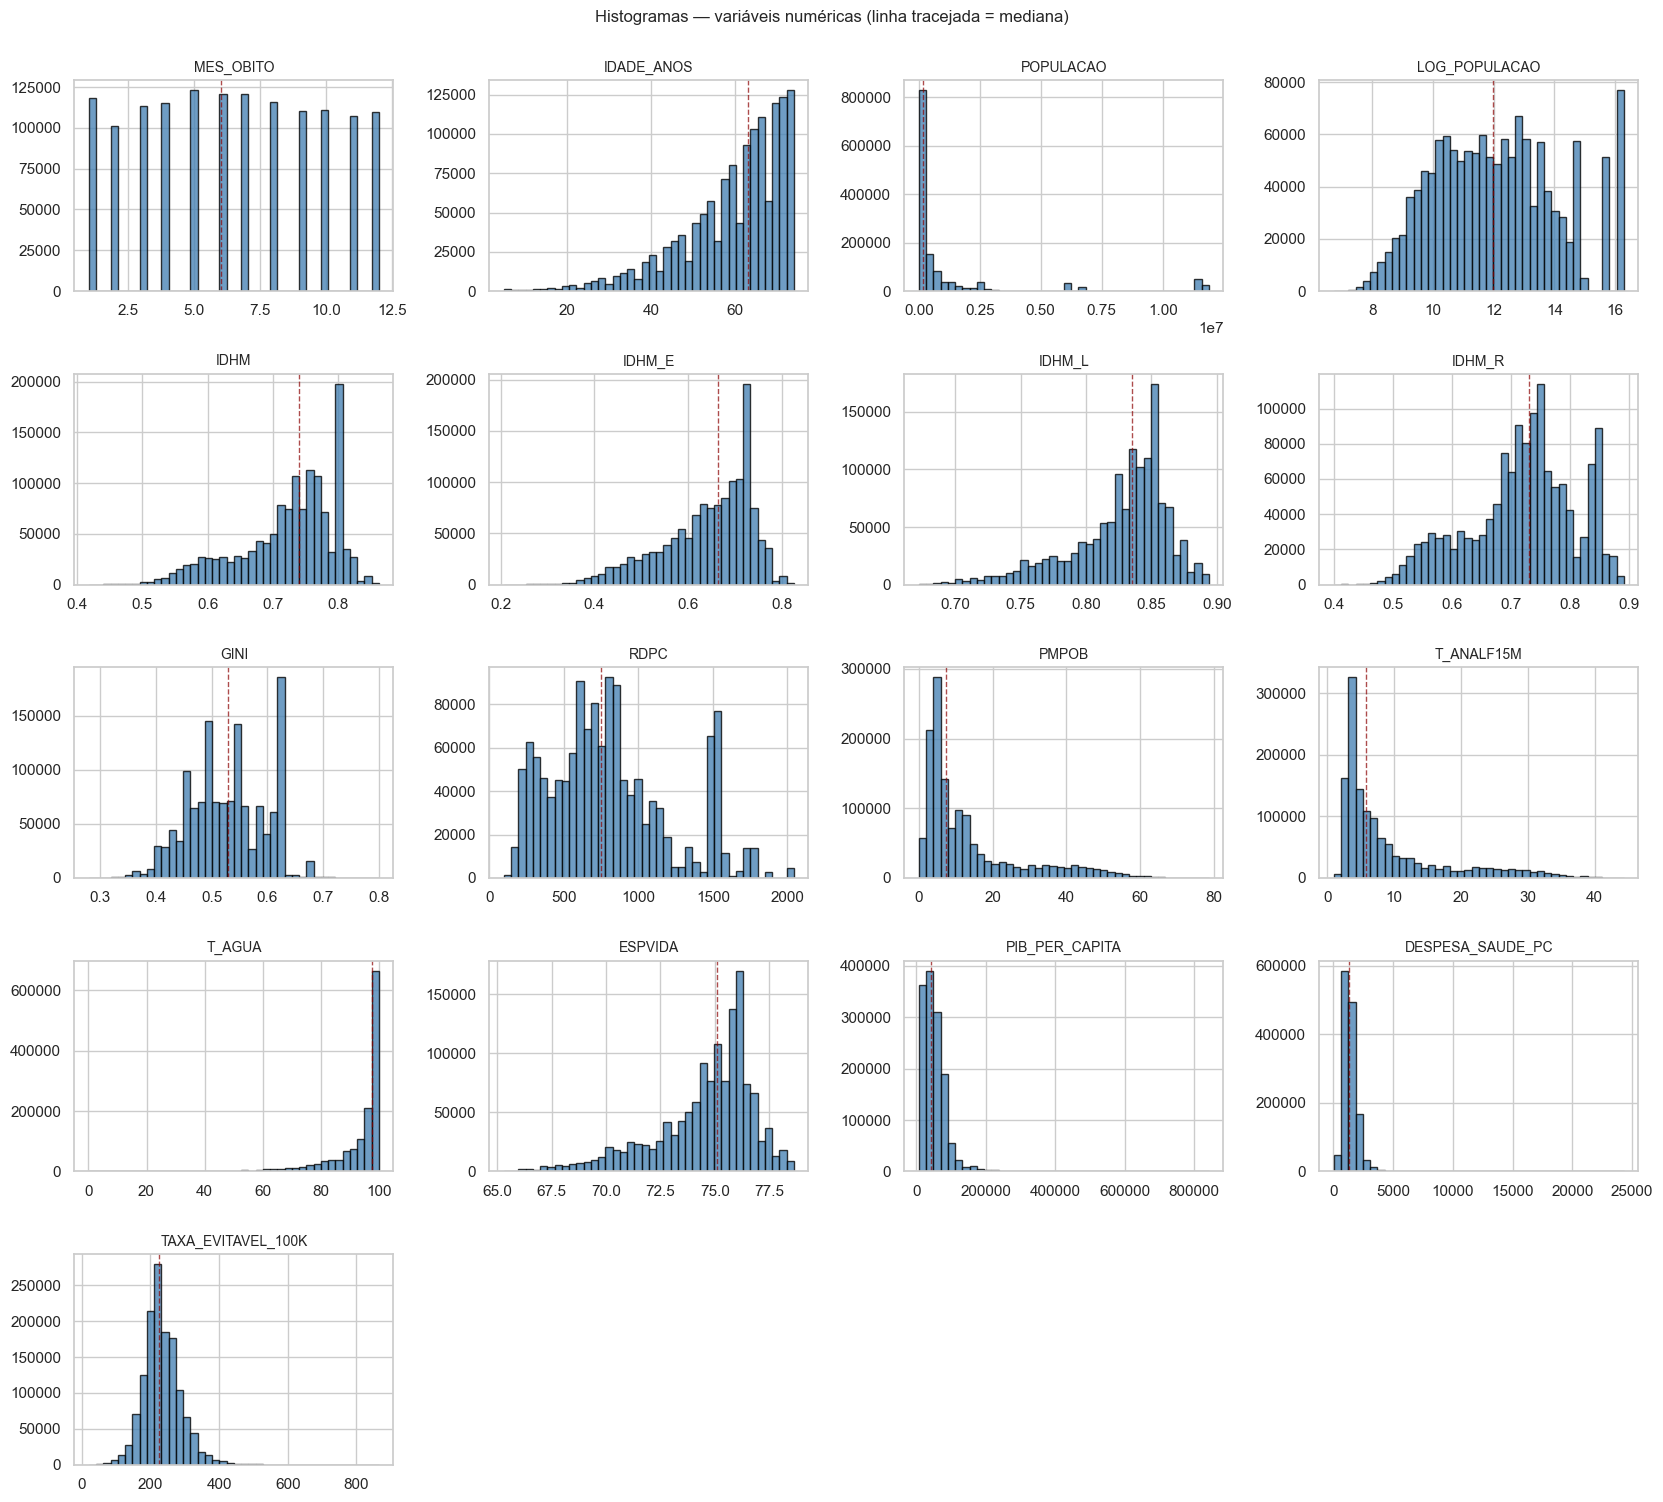

In [10]:
n_vars = len(vars_num)
n_cols = 4
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.0 * n_rows))
axes = axes.flatten()
for ax, var in zip(axes, vars_num):
    serie = mi[var].dropna()
    ax.hist(serie, bins=40, edgecolor="black", alpha=0.78, color="steelblue")
    ax.set_title(var, fontsize=10)
    ax.set_ylabel("")
    # Marca a mediana
    med = serie.median()
    ax.axvline(med, color="darkred", linestyle="--", linewidth=1, alpha=0.7)
for ax in axes[n_vars:]:
    ax.set_visible(False)
plt.suptitle("Histogramas — variáveis numéricas (linha tracejada = mediana)", y=1.0, fontsize=12)
plt.tight_layout(); plt.show()

### 8.1 Histogramas comparativos entre os 3 anos

Para um subconjunto de variáveis-chave que **variam ao longo do tempo** (taxa, despesa, idade), o histograma sobreposto por ano expõe drift entre 2022, 2023 e 2024.

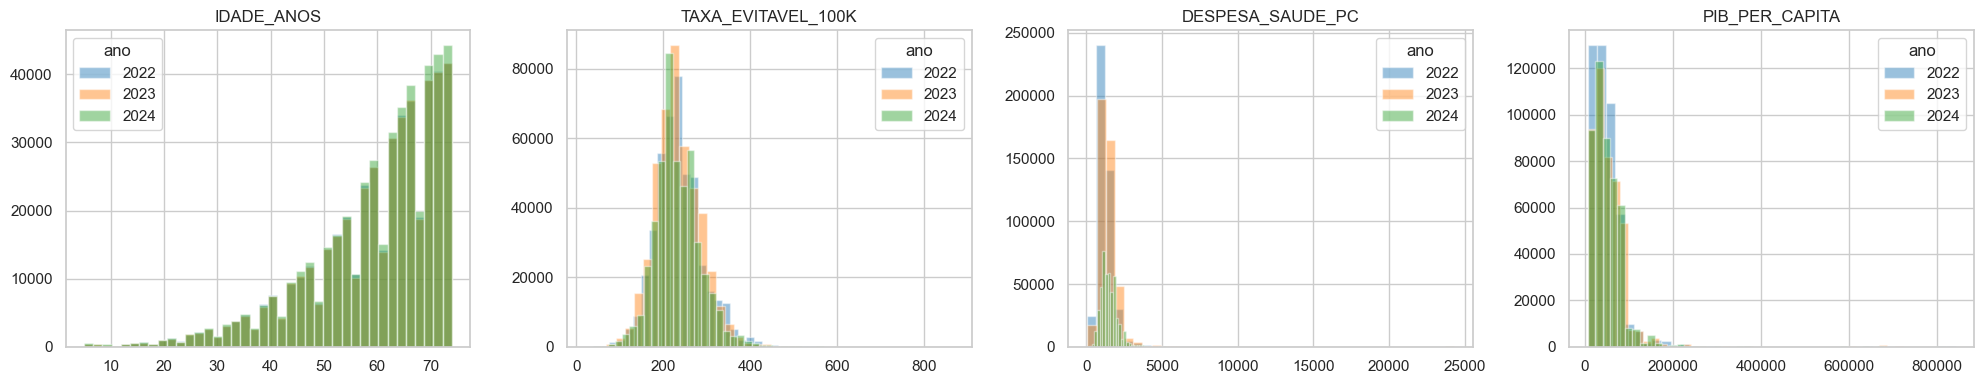

In [11]:
vars_drift = ["IDADE_ANOS", "TAXA_EVITAVEL_100K", "DESPESA_SAUDE_PC", "PIB_PER_CAPITA"]
anos       = sorted(mi["ANO_OBITO"].dropna().unique().tolist())
cores      = {2022: "#1f77b4", 2023: "#ff7f0e", 2024: "#2ca02c"}

fig, axes = plt.subplots(1, len(vars_drift), figsize=(5 * len(vars_drift), 4))
for ax, var in zip(axes, vars_drift):
    for ano in anos:
        s = mi.loc[mi["ANO_OBITO"] == ano, var].dropna()
        ax.hist(s, bins=40, alpha=0.45, label=str(ano),
                color=cores.get(int(ano), None), edgecolor="white")
    ax.set_title(var)
    ax.legend(title="ano")
plt.tight_layout(); plt.show()

## 9. Distribuição das categóricas — barplots

Para cada categórica, **percentual normalizado dentro de cada ano** — facilita ver se a composição mudou entre 2022 → 2024 (ex.: aumento de óbitos em domicílio vs. hospital).

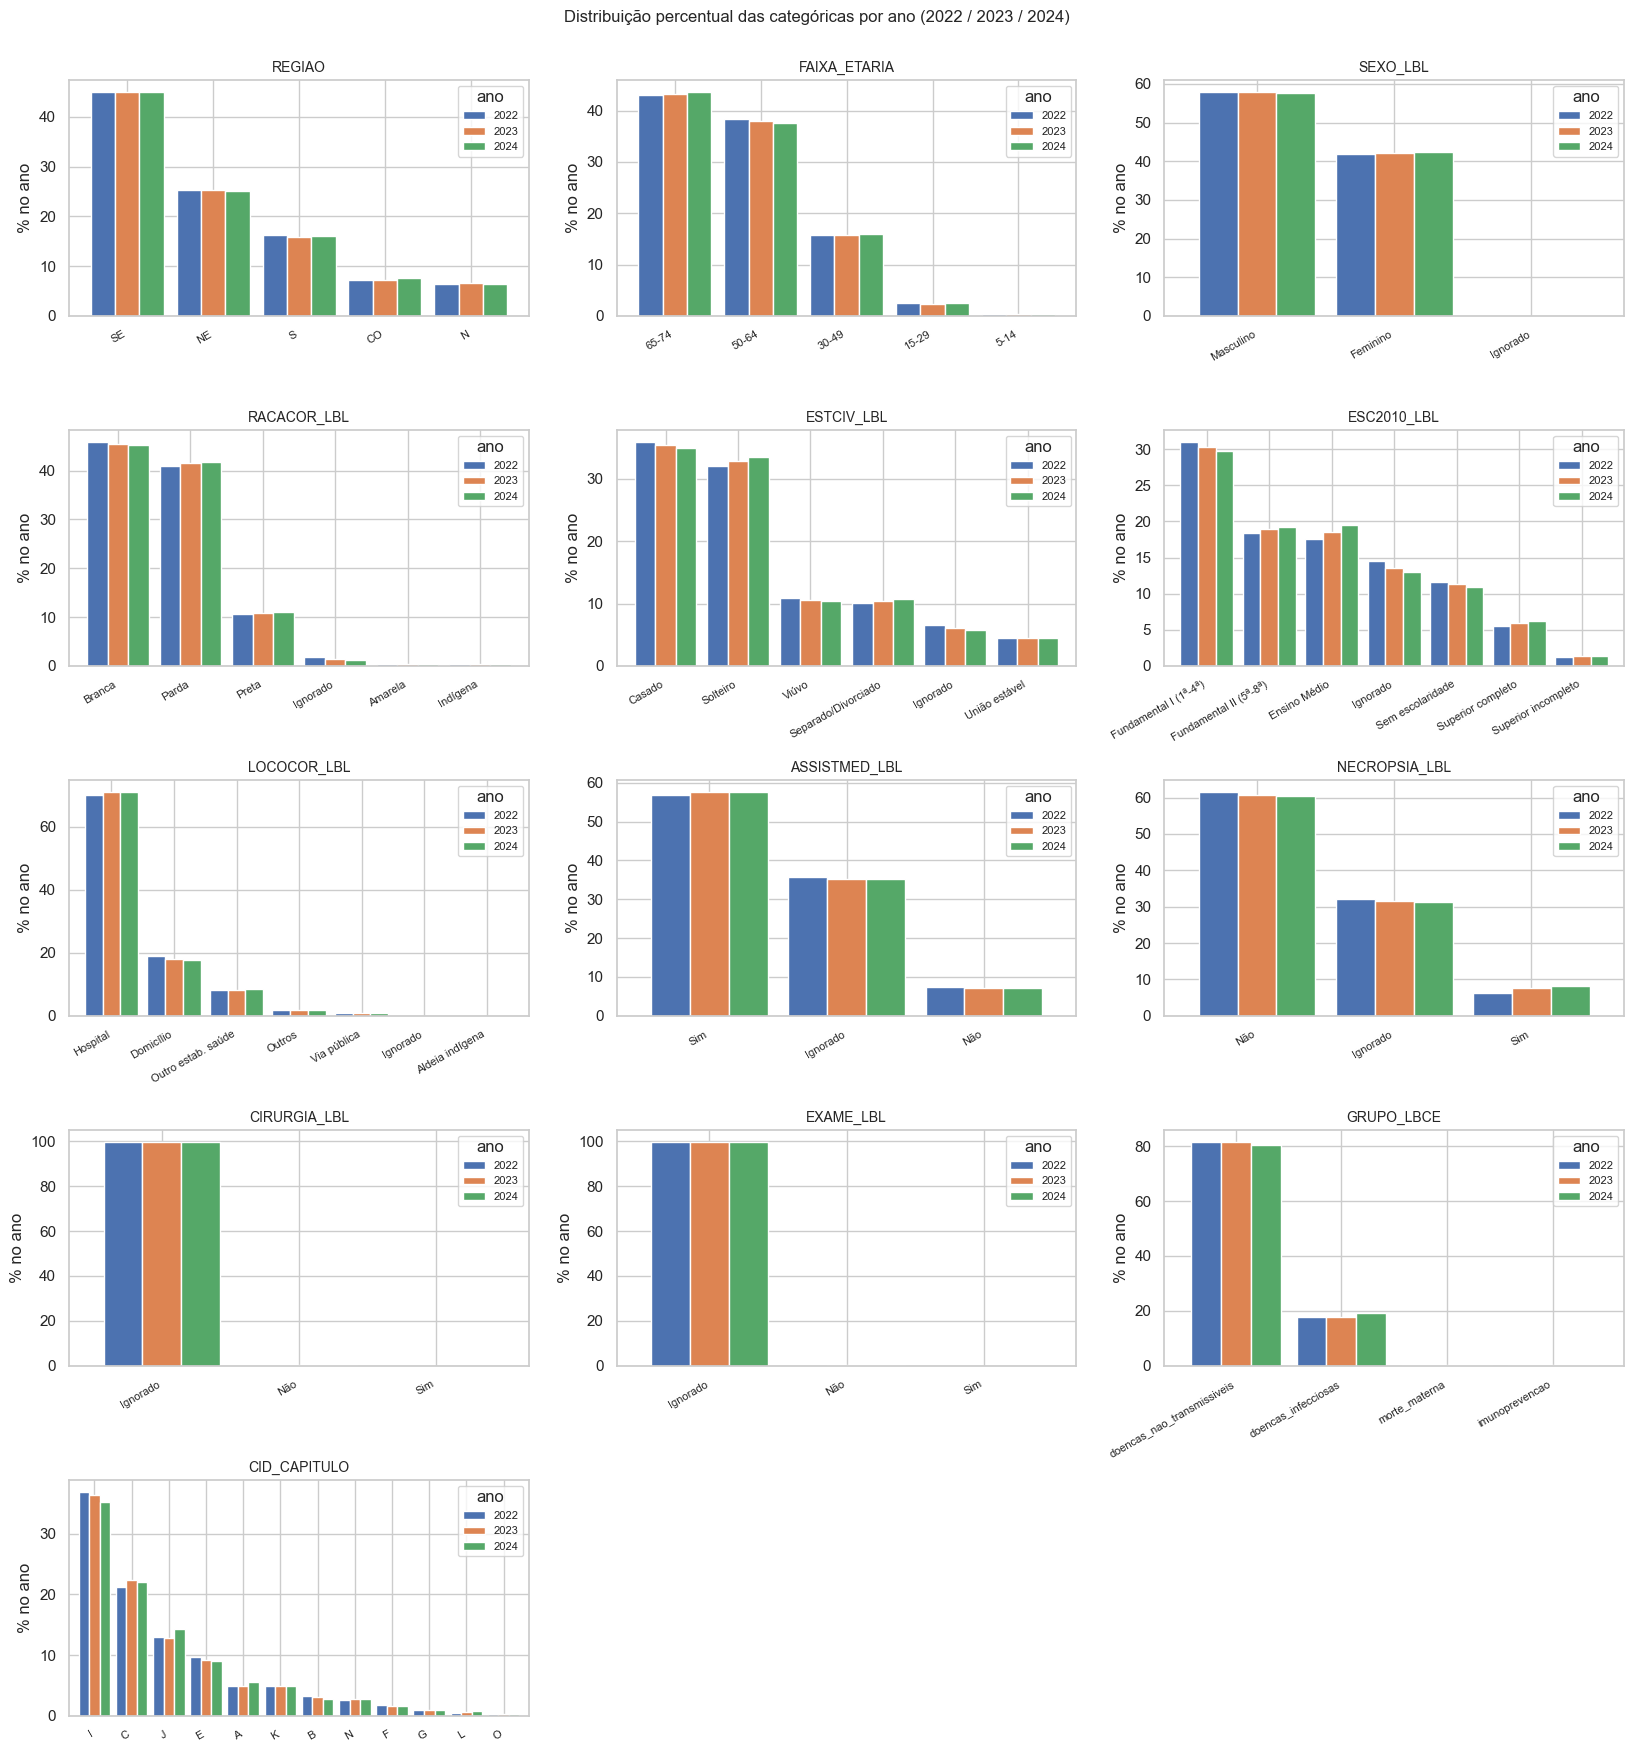

In [12]:
# Restringe às categóricas com cardinalidade pequena (≤ 12 níveis) — bons para barplot
vars_cat_plot = [c for c in vars_cat if mi[c].astype("object").nunique() <= 12]

n_cols = 3
n_rows = int(np.ceil(len(vars_cat_plot) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for ax, var in zip(axes, vars_cat_plot):
    ct = pd.crosstab(mi[var].astype("object"), mi["ANO_OBITO"], normalize="columns") * 100
    ct = ct.reindex(ct.sum(axis=1).sort_values(ascending=False).index)
    ct.plot(kind="bar", ax=ax, edgecolor="white", width=0.85)
    ax.set_title(var, fontsize=10)
    ax.set_ylabel("% no ano")
    ax.set_xlabel("")
    ax.legend(title="ano", fontsize=8)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)

for ax in axes[len(vars_cat_plot):]:
    ax.set_visible(False)
plt.suptitle("Distribuição percentual das categóricas por ano (2022 / 2023 / 2024)", y=1.0, fontsize=12)
plt.tight_layout(); plt.show()

### 9.1 Volume total de óbitos por ano e região

Visão de painel: quantos óbitos evitáveis foram registrados em cada combinação ano × região.

Óbitos evitáveis por ano × região:
REGIAO         N      NE     CO      SE      S
ANO_OBITO                                     
2022       28810  113937  32304  202206  73054
2023       29792  112647  32523  201278  70365
2024       30274  117203  35233  210716  75334


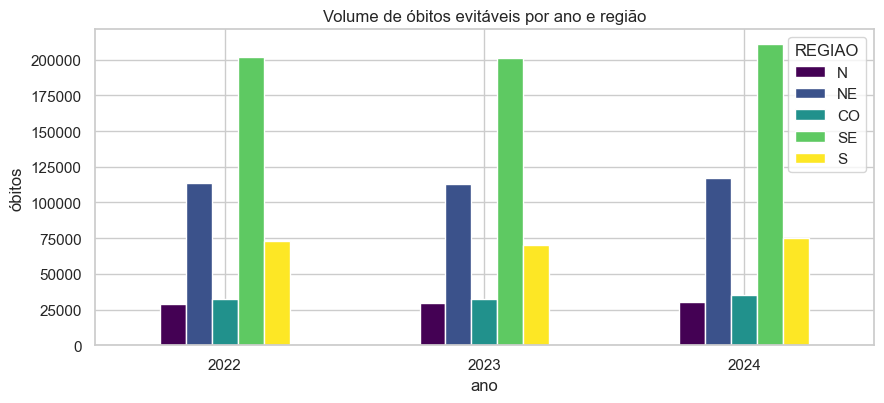

In [13]:
vol = mi.groupby(["ANO_OBITO", "REGIAO"]).size().unstack(fill_value=0)
vol = vol.reindex(columns=["N", "NE", "CO", "SE", "S"])
print("Óbitos evitáveis por ano × região:")
print(vol)

fig, ax = plt.subplots(figsize=(9, 4.2))
vol.plot(kind="bar", ax=ax, edgecolor="white", colormap="viridis")
ax.set_title("Volume de óbitos evitáveis por ano e região")
ax.set_ylabel("óbitos")
ax.set_xlabel("ano")
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

## 10. Persistência

Salva o dataset individualizado em `data/processed/microdados_evitaveis.parquet`. Esse arquivo será a entrada de notebooks futuros de clusterização de indivíduos e mineração de texto sobre causas.

In [14]:
out = PROCESSED_DIR / "microdados_evitaveis.parquet"
mi.to_parquet(out, index=False)
print(f"Salvo: {out.name} ({out.stat().st_size / 1e6:.1f} MB)")
print(f"Linhas: {len(mi):,}  |  Colunas: {mi.shape[1]}")

Salvo: microdados_evitaveis.parquet (33.9 MB)
Linhas: 1,366,467  |  Colunas: 34


---

**Resumo do que foi feito:**

- ~1.37M óbitos evitáveis (2022-2024) com decodificação completa dos códigos SIM (9 campos).
- 3 colunas derivadas: `FAIXA_ETARIA`, `MES_OBITO`, `CID_CAPITULO`.
- 15 colunas de contexto municipal (IDH-M, Gini, renda, despesa em saúde, etc.) anexadas via merge.
- Estatística descritiva completa: numéricas (`describe` + média por ano) e categóricas (`value_counts` + % por ano).
- Histogramas globais e comparativos entre os 3 anos.

**Próximos passos sugeridos:**
- **Clusterização de indivíduos** — K-Means ou Gower distance em features mistas (numéricas + categóricas) para identificar perfis típicos de morte evitável (ex.: "homem jovem do NE, com baixa escolaridade, óbito por causa infecciosa" vs. "mulher idosa do SE com cardiopatia").
- **Mineração de causas (CID-10)** — análise textual das descrições para identificar palavras-chave dominantes em cada cluster.